# **CHAPTER 5: Support Vector Machines**

**SVM finds the separating line (or plane) that maximizes the distance between classes, and this line is determined only by the closest training points called support vectors.**

Remember for Exams

- Decision Boundary → The line separating classes.
- Margin → Distance between classes and the boundary.
- Large Margin Classification → Choosing the widest possible margin.
- Support Vectors → Closest data points to the boundary.
- Goal of SVM → Maximize the margin to improve generalization on unseen data.

## **Soft Margin Classification**



### **Easy Memory Trick**
- Hard Margin = Strict Teacher → No mistakes allowed.
- Soft Margin = Practical Teacher → A few mistakes are okay if overall performance is better.


| Feature                            | Hard Margin | Soft Margin    |
| ---------------------------------- | ----------- | -------------- |
| Misclassification Allowed?         | No          | Yes            |
| Handles Outliers?                  | Poorly      | Well           |
| Requires Perfectly Separable Data? | Yes         | No             |
| Generalization                     | Often Worse | Usually Better |
| Used in Practice?                  | Rarely      | Very Common    |


### **The C Parameter**

- The parameter C controls how strict the SVM is.

**Large C**
- Tries to classify every point correctly.
- Behaves more like Hard Margin.
- Smaller margin.
- More sensitive to outliers.

**Small C**
- Allows more violations.
- Wider margin.
- More tolerant of outliers.
- Better generalization in many cases.


The Trade-off: A bunch of points (the circled ones) end up sitting right inside the street. These are called margin violations.


In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn import datasets
from sklearn.pipeline import Pipeline

iris = datasets.load_iris()

X = iris['data'][:, (2,3)]
y = (iris["target"] == 2).astype(np.float64)

In [6]:
svm_clf = Pipeline((
    ('scaler', StandardScaler()),
    ('LinearSVC', LinearSVC(C=1, loss='hinge'))
))

In [7]:
svm_clf.fit(X, y)


Pipeline(steps=[('scaler', StandardScaler()),
                ('LinearSVC', LinearSVC(C=1, loss='hinge'))])

In [8]:
svm_clf.predict([[5.5, 1.7]])

array([1.])

## **Nonlinear SVM Classification**

In [24]:
from sklearn.datasets import make_moons
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures


poly_svm_clf = Pipeline((
    ('poly_features', PolynomialFeatures(degree=3)),
    ('scaler', StandardScaler()),
    ('svm_clf', LinearSVC(C=0.10000, loss='hinge'))
))

poly_svm_clf.fit(X, y)

Pipeline(steps=[('poly_features', PolynomialFeatures(degree=3)),
                ('scaler', StandardScaler()),
                ('svm_clf', LinearSVC(C=0.1, loss='hinge'))])

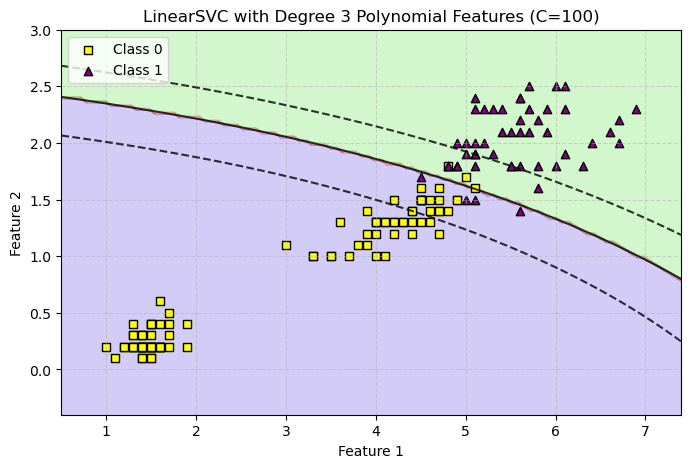

In [25]:
import matplotlib.pyplot as plt

def plot_predictions(clf, axes):
    """Generates a grid of points and plots the decision boundary."""
    # 1. Create a dense grid of points over the feature space
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    
    # 2. Flatten the grid to pass through the pipeline
    X_grid = np.c_[x0.ravel(), x1.ravel()]
    
    # 3. Predict the class and get the raw decision scores
    y_pred = clf.predict(X_grid).reshape(x0.shape)
    y_decision = clf.decision_function(X_grid).reshape(x0.shape)
    
    # 4. Plot the filled decision regions (light blue/red tinted background)
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)
    
    # 5. Plot the solid decision boundary (where score = 0) and margins (where score = +/-1)
    plt.contour(x0, x1, y_decision, levels=[-1, 0, 1], alpha=0.8,
                linestyles=['--', '-', '--'], colors=['black', 'black', 'black'])

# --- How to use it with your data ---

# Set your plot limits based on your actual data ranges [xmin, xmax, ymin, ymax]
# For example, if you are using the moon dataset or iris petal data:
axes_limits = [X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 
               X[:, 1].min() - 0.5, X[:, 1].max() + 0.5]

plt.figure(figsize=(8, 5))

# Plot your background decision boundary
plot_predictions(poly_svm_clf, axes_limits)

# Plot your actual scatter points on top
plt.scatter(X[y == 0, 0], X[y == 0, 1], marker="s", color="yellow", label="Class 0", edgecolors='k')
plt.scatter(X[y == 1, 0], X[y == 1, 1], marker="^", color="purple", label="Class 1", edgecolors='k')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(loc="upper left")
plt.title(f"LinearSVC with Degree 3 Polynomial Features (C=100)")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# **Polynomial Kernel**


In [31]:
from sklearn.svm import SVC

poly_svc_clf = Pipeline((
    ('scaler', StandardScaler()),
    ('svm_clf', SVC(kernel='poly', degree=10, coef0=1, C=10))
))

poly_svc_clf.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm_clf', SVC(C=10, coef0=1, degree=10, kernel='poly'))])

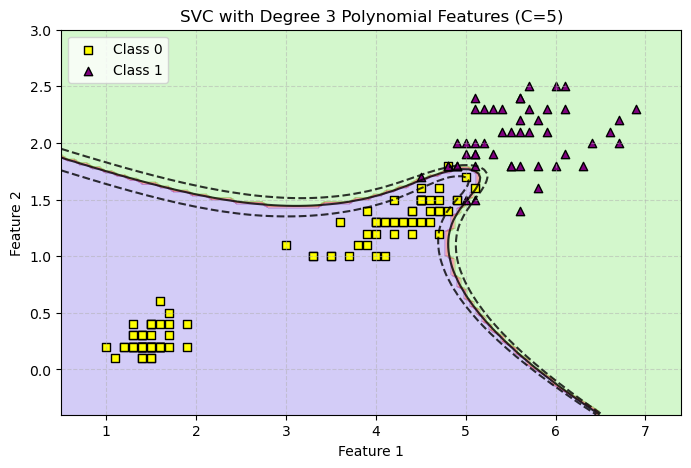

In [32]:
# --- How to use it with your data ---

# Set your plot limits based on your actual data ranges [xmin, xmax, ymin, ymax]
# For example, if you are using the moon dataset or iris petal data:
axes_limits = [X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 
               X[:, 1].min() - 0.5, X[:, 1].max() + 0.5]

plt.figure(figsize=(8, 5))

# Plot your background decision boundary
plot_predictions(poly_svc_clf, axes_limits)

# Plot your actual scatter points on top
plt.scatter(X[y == 0, 0], X[y == 0, 1], marker="s", color="yellow", label="Class 0", edgecolors='k')
plt.scatter(X[y == 1, 0], X[y == 1, 1], marker="^", color="purple", label="Class 1", edgecolors='k')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(loc="upper left")
plt.title(f"SVC with Degree 3 Polynomial Features (C=5)")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

## **Adding Similarity Features Or Similarity Function**
- Another technique to tackle nonlinear problems is to add features computed using a similarity function that measures how much each instance resembles a particular landmark

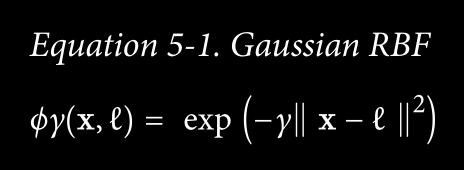

Gaussian Radial Basis Function (RBF)
with γ

## **Gaussian RBF Kernel**

In [39]:
rbf_kernel_svm_clf = Pipeline((
("scaler", StandardScaler()),
("svm_clf", SVC(kernel="rbf", gamma=5, C=1))
))
rbf_kernel_svm_clf.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()), ('svm_clf', SVC(C=1, gamma=5))])

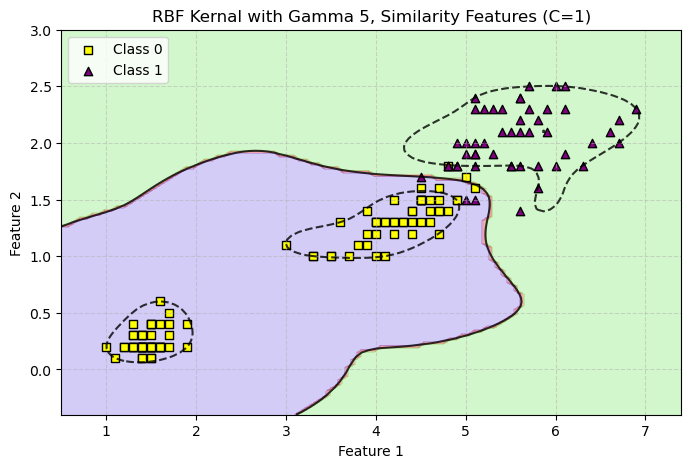

In [41]:
# --- How to use it with your data ---

# Set your plot limits based on your actual data ranges [xmin, xmax, ymin, ymax]
# For example, if you are using the moon dataset or iris petal data:
axes_limits = [X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 
               X[:, 1].min() - 0.5, X[:, 1].max() + 0.5]

plt.figure(figsize=(8, 5))

# Plot your background decision boundary
plot_predictions(rbf_kernel_svm_clf, axes_limits)

# Plot your actual scatter points on top
plt.scatter(X[y == 0, 0], X[y == 0, 1], marker="s", color="yellow", label="Class 0", edgecolors='k')
plt.scatter(X[y == 1, 0], X[y == 1, 1], marker="^", color="purple", label="Class 1", edgecolors='k')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(loc="upper left")
plt.title(f"RBF Kernal with Gamma 5, Similarity Features (C=1)")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# **SVM Regression**

In [20]:
print(X[95:105], "  ", y[95:105])

[[4.2 1.2]
 [4.2 1.3]
 [4.3 1.3]
 [3.  1.1]
 [4.1 1.3]
 [6.  2.5]
 [5.1 1.9]
 [5.9 2.1]
 [5.6 1.8]
 [5.8 2.2]]    [0. 0. 0. 0. 0. 1. 1. 1. 1. 1.]


In [21]:
from sklearn.svm import LinearSVR

svm_reg = LinearSVR(epsilon=1.5)
svm_reg.fit(X, y)

LinearSVR(epsilon=1.5)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import SVR

poly_svm_reg = Pipeline([
    ("poly_features", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("svm_reg", SVR(kernel="linear", C=100, epsilon=0.1)) # Change C to 0.01 to see the right plot
])

poly_svm_reg.fit(X, y)

Pipeline(steps=[('poly_features', PolynomialFeatures(include_bias=False)),
                ('scaler', StandardScaler()),
                ('svm_reg', SVR(C=100, kernel='linear'))])

In [ ]:
def plot_svm_regression_2d(svm_reg, X, y, axes):
    """Plots a 2D dataset and overlays the SVR prediction surface as a contour."""
    # 1. Create a dense 2D grid covering both features
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    
    # 2. Combine them into a 2-column input matrix to satisfy the pipeline
    X_grid = np.c_[x0.ravel(), x1.ravel()]
    
    # 3. Predict y values across the entire grid surface
    y_pred = svm_reg.predict(X_grid).reshape(x0.shape)
    
    # 4. Extract epsilon to calculate the margin boundaries
    epsilon = svm_reg.named_steps["svm_reg"].epsilon
    
    # 5. Plot the prediction surface as filled contours (the darker the color, the higher the predicted y)
    contour = plt.contourf(x0, x1, y_pred, levels=20, cmap="twilight_r", alpha=0.6)
    plt.colorbar(contour, label="Predicted value ($\hat{y}$)")
    
    # 6. Scatter your actual data points on top (colored by their true 'y' value)
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), s=50, cmap="twilight_r", edgecolors="k", linewidth=0.8)
    
    plt.axis(axes)
    plt.xlabel("Feature 1 ($x_1$)")
    plt.ylabel("Feature 2 ($x_2$)")
    plt.grid(True, linestyle="--", alpha=0.3)

# --- Execute the Updated Plotting ---
plt.figure(figsize=(9, 6))

# Define limits for both Feature 1 and Feature 2: [x1_min, x1_max, x2_min, x2_max]
axes_limits = [X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 
               X[:, 1].min() - 0.5, X[:, 1].max() + 0.5]

plot_svm_regression_2d(poly_svm_reg, X, y, axes_limits)
plt.title(r"SVR 2D Prediction Surface (degree=2, $\epsilon=0.1$)")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Define the input data points
x_coords = np.array([1, 2, 3, 4, 5])
y_coords = np.array([2, 4, 6, 8, 10]) 
z_coords = np.array([3, 5, 7, 9, 11])

# 2. Create a grid for the 3D surface plot
X, Y = np.meshgrid(np.linspace(1, 5, 20), np.linspace(2, 10, 20))

# 3. Define a linear decision function plane h = w1*X + w2*Y + b
Z_plane = 1.5 * X + 0.2 * Y - 2.0 

# 4. Set up the plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 5. Plot the decision function surface (the grid plane)
surf = ax.plot_surface(X, Y, Z_plane, cmap='viridis', alpha=0.6, 
                       edgecolor='white', linewidth=0.5)

# 6. Plot the reference zero-plane (the yellow/green flat plane where h=0)
Z_zero = np.zeros_like(X)
ax.plot_surface(X, Y, Z_zero, color='yellow', alpha=0.3, shade=False)

# 7. Highlight the Decision Boundary (where the two planes intersect: h = 0)
ax.contour(X, Y, Z_plane, levels=[0], colors=['white'], linewidths=3, linestyles='solid')

# 8. Highlight the Margin Boundaries (where h = 1 and h = -1)
ax.contour(X, Y, Z_plane, levels=[-1, 1], colors=['white'], linewidths=1.5, linestyles='dashed')

# 9. Plot data points dynamically matching sliced array shapes
ax.scatter(x_coords[:2], y_coords[:2], np.zeros_like(x_coords[:2]), color='white', marker='s', s=50, edgecolors='black', label='Class 1')
ax.scatter(x_coords[2:], y_coords[2:], np.zeros_like(x_coords[2:]), color='white', marker='^', s=50, edgecolors='black', label='Class 2')

# 10. Customizations & Styling
ax.set_xlabel('Petal length', fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel('Petal width', fontsize=11, fontweight='bold', labelpad=10)
ax.set_zlabel('$h = \mathbf{w}^T\mathbf{x} + b$', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('Decision Function for the Dataset', fontsize=14, pad=20)

ax.set_facecolor('#1c1c1c') 
fig.patch.set_facecolor('#1c1c1c')

ax.xaxis.set_pane_color((0.1, 0.1, 0.1, 1.0))
ax.yaxis.set_pane_color((0.1, 0.1, 0.1, 1.0))
ax.zaxis.set_pane_color((0.1, 0.1, 0.1, 1.0))

ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.zaxis.label.set_color('white')

ax.view_init(elev=20, azim=-60)

plt.show()

# **Exercises**

```
**1. What is the fundamental idea behind Support Vector Machines?**

**Ans: ** how we can sperate two class using the decesion boundary
s
```

```

2. What is a support vector?

Support vectors are the nearest training points to the decision boundary that define the SVM's margin and hyperplane.

```

```
3. Why is it important to scale the inputs when using SVMs?

SVM calculates distances and margins. If one feature has much larger values than another, it dominates the distance calculations and can produce a poor decision boundary.
```


```
4. Can an SVM classifier output a confidence score when it classifies an instance?
What about a probability?

SVM outputs a confidence score using the decision function but does not provide probabilities unless probability calibration is applied.
```

```
5. Should you use the primal or the dual form of the SVM problem to train a model
on a training set with millions of instances and hundreds of features?

Use the primal form for large datasets because it scales with the number of features, while the dual form becomes too slow as the number of training instances grows.

```


```
6. Say you trained an SVM classifier with an RBF kernel. It seems to underfit the
training set: should you increase or decrease γ (gamma)? What about C?

C controls regularization (margin vs errors), while gamma controls how far each data point influences the decision boundary in nonlinear SVMs.
```

9. Train an SVM classifier on the MNIST dataset. Since SVM classifiers are binary
classifiers, you will need to use one-versus-all to classify all 10 digits. You may
want to tune the hyperparameters using small validation sets to speed up the process. What accuracy can you reach?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC, SVR, LinearSVC
from sklearn.preprocessing import StandardScaler

from sklearn.datasets import fetch_openml

from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1)

X, y = mnist.data, mnist.target


In [3]:
print(mnist.DESCR)

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

In [ ]:
n = X.iloc[0]
for i in n:
    print(i)


In [5]:
X.iloc[0]     # 28 * 28 = 784

pixel1      0
pixel2      0
pixel3      0
pixel4      0
pixel5      0
           ..
pixel780    0
pixel781    0
pixel782    0
pixel783    0
pixel784    0
Name: 0, Length: 784, dtype: int64

In [45]:
from PIL import Image
import numpy as np

img = Image.open("/home/noneo/Codes/ML/MachineLearning/1777742595668.jpeg").convert('RGB')
img_array = np.array(img)


In [46]:
print(img_array)

[[[199 199 199]
  [199 199 199]
  [199 199 199]
  ...
  [224 224 226]
  [224 224 226]
  [224 224 226]]

 [[199 199 199]
  [199 199 199]
  [199 199 199]
  ...
  [224 224 226]
  [224 224 226]
  [224 224 226]]

 [[198 198 198]
  [199 199 199]
  [199 199 199]
  ...
  [224 224 226]
  [224 224 226]
  [224 224 226]]

 ...

 [[200 200 200]
  [200 200 200]
  [201 201 201]
  ...
  [205 205 207]
  [205 205 207]
  [205 205 207]]

 [[200 200 200]
  [200 200 200]
  [201 201 201]
  ...
  [205 205 207]
  [205 205 207]
  [205 205 207]]

 [[199 199 199]
  [200 200 200]
  [201 201 201]
  ...
  [205 205 207]
  [205 205 207]
  [205 205 207]]]


In [ ]:
R = img_array[:, :, 0]
G = img_array[:, :, 1]
B = img_array[:, :, 2]

In [ ]:

# 3. Display the original image
plt.figure(figsize=(5, 5))
plt.imshow(img_array)
plt.title("Original Image")
plt.axis("off")
plt.show()


In [ ]:
# channels = [R, G, B]
# titles = ["Reds", "Greens", "Blues"]

# for channel, title in zip(channels, titles):
#     plt.figure(figsize=(5, 5))
#     plt.imshow(channel, cmap="gray")
#     plt.title(title)
#     plt.axis("off")
#     plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Method 1: Using matplotlib
fig, axes = plt.subplots(1, 4, figsize=(12, 4))

# Original image
axes[0].imshow(img_array)
axes[0].set_title('Original RGB')
axes[0].axis('off')

# Red channel
axes[1].imshow(R, cmap='Reds')
axes[1].set_title('Red Channel')
axes[1].axis('off')

# Green channel
axes[2].imshow(G, cmap='Greens')
axes[2].set_title('Green Channel')
axes[2].axis('off')

# Blue channel
axes[3].imshow(B, cmap='Blues')
axes[3].set_title('Blue Channel')
axes[3].axis('off')

plt.show()

In [ ]:
first_image = X.iloc[5].values.reshape(28, 28)

plt.figure(figsize=(6, 6))
plt.imshow(first_image, cmap='gray')
plt.title('First Image')
plt.axis('off')
plt.show()


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [7]:
ss = StandardScaler()
X_train_scale = ss.fit_transform(X_train)
X_test_scale = ss.transform(X_test)


In [8]:
svm = SVC(kernel='rbf', random_state=42)


In [9]:
X_train_small, X_val, y_train_small, y_val = train_test_split(
    X_train_scale, y_train, test_size=0.2, random_state=42
)

In [10]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.001],
    'kernel': ['rbf']
}


In [11]:
svm_tune = SVC(random_state=42)
grid_search = GridSearchCV(
    svm_tune, 
    param_grid, 
    cv=3,
    n_jobs=-1,
    verbose=1
)


In [ ]:
grid_search.fit(X_train_small, y_train_small)


Fitting 3 folds for each of 16 candidates, totalling 48 fits


In [ ]:
print("best params: ", grid_search.best_params_)
print("best C-Val score: ",grid_search.best_score_)

# **Reamaining Practice Question**

10. Train an SVM regressor on the California housing dataset.

7. Train and fine-tune a Decision Tree for the moons dataset.
a. Generate a moons dataset using make_moons(n_samples=10000, noise=0.4).
b. Split it into a training set and a test set using train_test_split().
c. Use grid search with cross-validation (with the help of the GridSearchCV
class) to find good hyperparameter values for a DecisionTreeClassifier.
Hint: try various values for max_leaf_nodes.
d. Train it on the full training set using these hyperparameters, and measure
your model’s performance on the test set. You should get roughly 85% to 87%
accuracy

